# Análise de Rendimento Agrícola com Machine Learning

Este projeto tem como objetivo analisar dados climáticos relacionados à produção agrícola e aplicar técnicas de Machine Learning para prever o rendimento das culturas.

Serão realizadas etapas de análise exploratória, clusterização, identificação de outliers e construção de modelos preditivos.

## 1 - Análise Exploratória

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
df = pd.read_csv("../data/crop_yield.csv")

In [129]:
df.head(5)

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [131]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [132]:
df.shape

(156, 6)

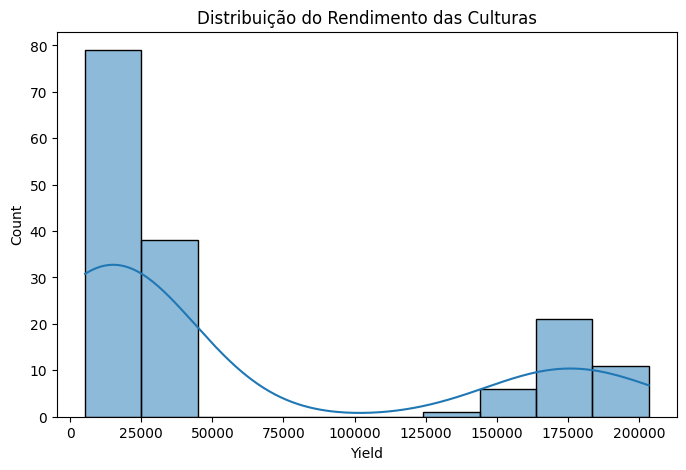

In [133]:
plt.figure(figsize=(8,5))

sns.histplot(df["Yield"], kde=True)

plt.title("Distribuição do Rendimento das Culturas")

plt.show()

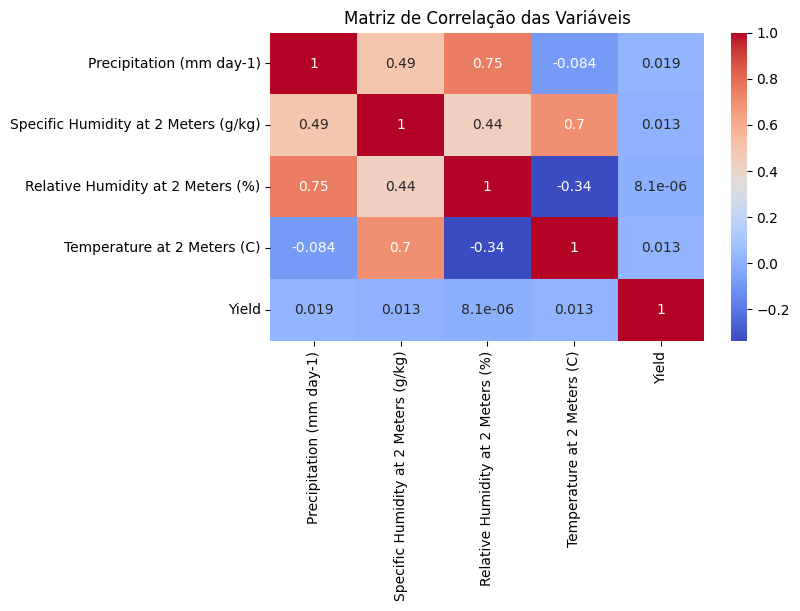

In [134]:
plt.figure(figsize=(7,4))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação das Variáveis")

plt.show()

## 2 - Clusterização dos dados

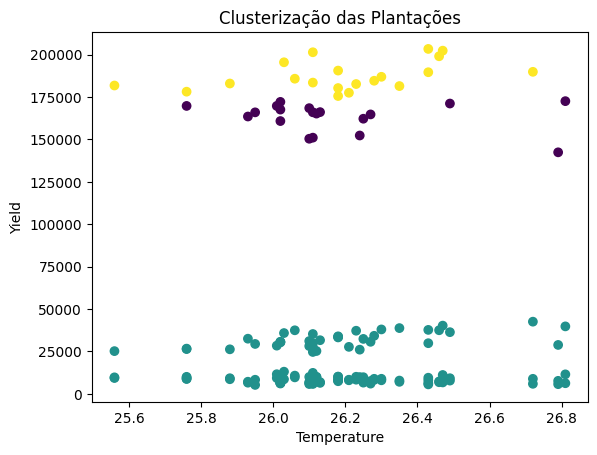

In [135]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_cluster = df[['Precipitation (mm day-1)',
                'Specific Humidity at 2 Meters (g/kg)',
                'Relative Humidity at 2 Meters (%)',
                'Temperature at 2 Meters (C)',
                'Yield']]

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_cluster)

df['Cluster'] = clusters

plt.scatter(df['Temperature at 2 Meters (C)'], df['Yield'], c=df['Cluster'])

plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.title("Clusterização das Plantações")

plt.show()

## 3- Identificação de Outliers

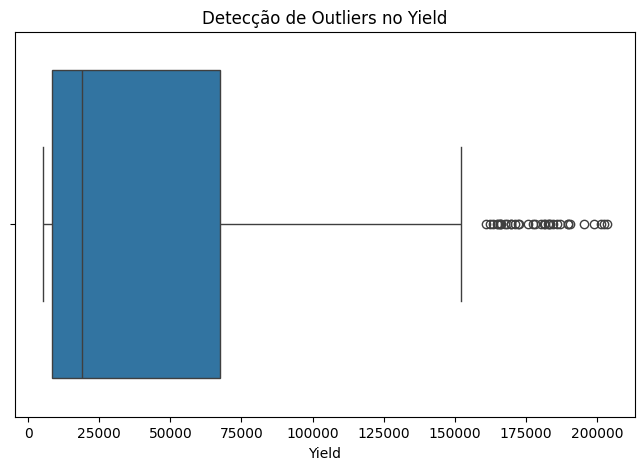

In [136]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Yield'])

plt.title("Detecção de Outliers no Yield")

plt.show()

## 4 - Modelos Preditivos

In [137]:
X = df.drop(["Yield", "Crop", "Cluster"], axis=1)
y = df["Yield"]

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4.1 - Modelo Linear Regression

In [139]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [140]:
y_pred = model.predict(X_test)

In [141]:
from sklearn.metrics import mean_squared_error, r2_score

print("Erro Quadrático Médio:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Erro Quadrático Médio: 4162255539.8433723
R2 Score: -0.07303066291166038


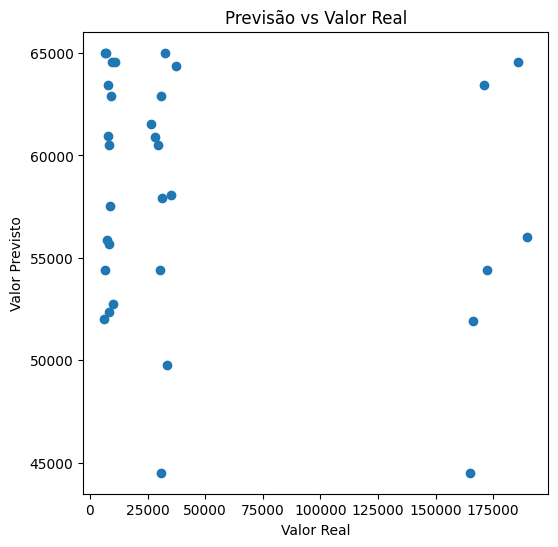

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Previsão vs Valor Real")

plt.show()

### 4.2 - Modelo Decision Tree

In [143]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_tree))
print("Decision Tree R2:", r2_score(y_test, y_pred_tree))

Decision Tree MSE: 8525193206.315972
Decision Tree R2: -1.1977972351902855


### 4.3 - Modelo Random Forest

In [144]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest MSE: 7405960032.9082775
Random Forest R2: -0.9092586045084283


### 4.4 - Modelo KNN

In [145]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))
print("KNN R2:", r2_score(y_test, y_pred_knn))

KNN MSE: 5745343715.025
KNN R2: -0.4811512450820372


### 4.5 - Modelo SVR

In [146]:
from sklearn.svm import SVR

svr_model = SVR()

svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score

print("SVR MSE:", mean_squared_error(y_test, y_pred_svr))
print("SVR R2:", r2_score(y_test, y_pred_svr))

SVR MSE: 5085640862.355417
SVR R2: -0.31107966188669267


## 5 - Avaliação de Modelos

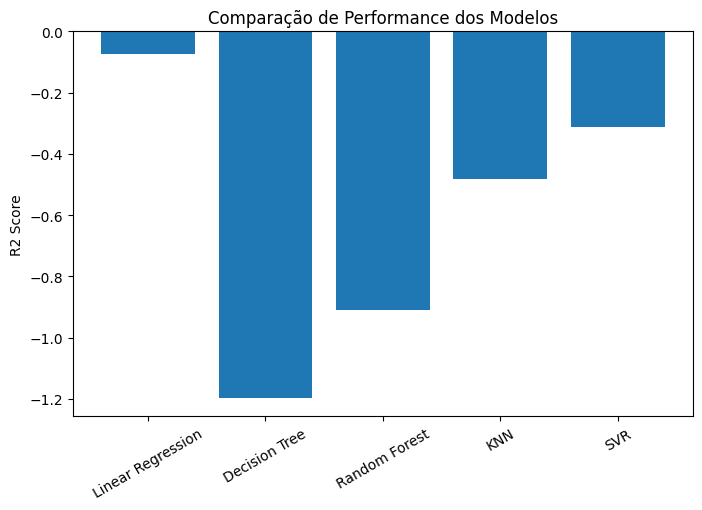

In [147]:
models = ["Linear Regression", "Decision Tree", "Random Forest", "KNN", "SVR"]

r2_scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_tree),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_knn),
    r2_score(y_test, y_pred_svr)
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.title("Comparação de Performance dos Modelos")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)

plt.show()

## 6 - Conclusão

Neste projeto foram aplicadas técnicas de análise exploratória, clusterização e identificação de outliers para explorar padrões e a possível existência de cenários discrepantes, assim, compreendendo melhor os dados relacionados ao rendimento agrícola.

Posteriormente, foram desenvolvidos cinco modelos de Machine Learning com o objetivo de prever o rendimento das culturas com base em variáveis climáticas.

Os modelos avaliados foram Linear Regression, Decision Tree, Random Forest, KNN e SVR, que utilizam métricas como MSE e R², permitindo comparar o desempenho entre diferentes algoritmos.

Os resultados mostraram que os modelos apresentaram baixo desempenho preditivo, indicando que as variáveis disponíveis podem não explicar completamente a variação no rendimento das safras.

